<a href="https://colab.research.google.com/github/newts0fa/ml-basics/blob/main/%E2%84%963%20%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_%D0%BF%D0%BE_Pandas_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №3. Библиотека Pandas. Визуальный анализ данных

Воронов Илья 2024-ФГИИБ-ПИ-1Б


## Комплексное задание №1. Применение основных методов для анализа данных

1. Скачайте этот блокнот к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат в своём гитхаб репозитории.

#### Полезная литература
- [**Блокнот с теорией**](https://colab.research.google.com/drive/1SLqmaYz4xEsxVV-LGwb3ityheBTzHJQu?usp=sharing)
- http://pandas.pydata.org/pandas-docs/stable/10min.html
- https://pandas.pydata.org/pandas-docs/stable/indexing.html
- https://pandas.pydata.org/pandas-docs/stable/missing_data.html

В этом задании мы с Вами рассмотрим датасет [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/Adult).
Основывается он на данных переписи населения 1994 года в США.

Расшифровка содержимого колонок:

- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous. sampling weight, more here: SIPP Weighting.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous. Income from investment sources, apart from wages/salary.
- capital-loss: continuous. Losses from investment sources, apart from wages/salary.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [ ]:
%matplotlib inline
import pandas as pd
pd.__version__

'2.2.2'

Если вы увидели warning, не переживайте, всё хорошо.
- https://stackoverflow.com/questions/40845304/runtimewarning-numpy-dtype-size-changed-may-indicate-binary-incompatibility
- https://github.com/numpy/numpy/pull/432

In [ ]:
columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
# df = pd.read_csv('../../data/adult.csv.gz', na_values='?') # можно загрузить из файла или URL
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', na_values=' ?', names=columns)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


1) Выведите последние 10 элеметнов датасета

In [ ]:
df.tail(10)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


2) Сколько колонок и сколько строк в этом датасете?

In [ ]:
print(f'строк: {df.shape[0]}')
print(f'столбцов: {df.shape[1]}')


строк: 32561
столбцов: 15


3) Какие типы данных у элементов этого датасета?

In [ ]:
df.dtypes.to_frame('dtype')


,dtype
age,int64
workclass,object
fnlwgt,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object


4) Какие признаки имеют пропуски?

In [ ]:
missing_features = df.isna().sum()
missing_features[missing_features > 0]


,0
workclass,1836
occupation,1843
native.country,583


5) Как вы думаете, с чем связаны пропуски этих значение. Напишите развернутый ответ в ячейке ниже.

Ваш ответ:

Скорее всего, эти пропуски связаны с тем, что часть людей не указала информацию в анкете или она не была корректно зафиксирована при сборе данных. В этом датасете пропуски больше похожи не на техническую ошибку, а на неизвестные или неприменимые значения, особенно для `workclass`, `occupation` и `native.country`.


6) Какие и сколько различных рабочих классов workclass представлено в выборке?

In [ ]:
workclass_counts = df['workclass'].value_counts(dropna=False)

print(f'различных рабочих классов без учёта пропусков: {df["workclass"].nunique()}')
workclass_counts


различных рабочих классов без учёта пропусков: 8


,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
NaN,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


7) Какой средний возраст женщин и мужчин?

In [ ]:
df.groupby('sex')['age'].mean().round(2)


,age
sex,
Female,36.86
Male,39.43


8) Постройте гистограмму(bar) распределения образования людей (education)

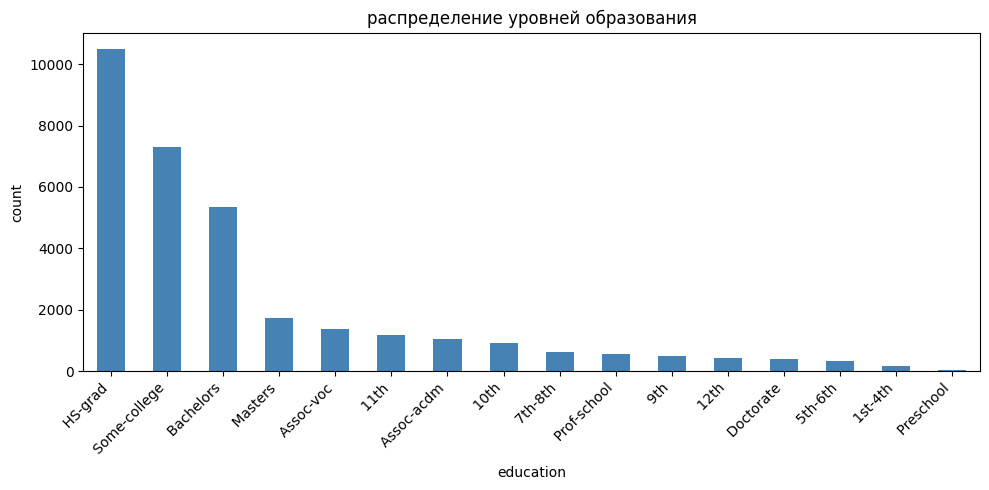

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
df['education'].value_counts().plot(kind='bar', color='steelblue')
plt.xlabel('education')
plt.ylabel('count')
plt.title('распределение уровней образования')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


9) Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает более 50K в год (признак income) и тех, кто получает менее 50K в год?

In [ ]:
df.groupby('income')['age'].agg(['mean', 'std']).round(2)


,mean,std
income,,
<=50K,36.78,14.02
>50K,44.25,10.52


10) Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education - Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)

In [ ]:
higher_education = {
    'Bachelors',
    'Prof-school',
    'Assoc-acdm',
    'Assoc-voc',
    'Masters',
    'Doctorate'
}

high_income = df[df['income'] == '>50K']
only_higher_education = high_income['education'].isin(higher_education).all()

print(only_higher_education)
high_income.loc[~high_income['education'].isin(higher_education), 'education'].value_counts()


True


,count
education,


11) Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми.

In [ ]:
men = df[df['sex'] == 'Male'].copy()
men['married_group'] = men['marital.status'].str.startswith('Married').map({
    True: 'Married',
    False: 'Not married'
})

income_share = men.groupby('married_group')['income'].apply(lambda s: (s == '>50K').mean()).mul(100).round(2)
income_share


,income
married_group,


12) Постройте [сводную таблицу](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) для отображения зависимостей среднего времени работы (hours.per.week) с доходом (income) для каждой страны (native.country).  


> Пример фрагмента таблицы:



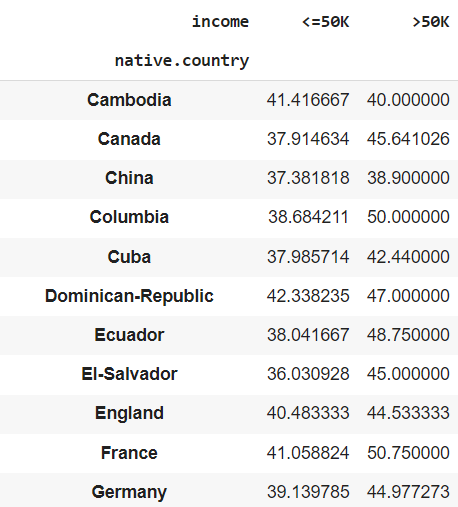

In [ ]:
pd.pivot_table(
    df,
    index='native.country',
    columns='income',
    values='hours.per.week',
    aggfunc='mean'
).sort_index()


income,<=50K,>50K
native.country,,
Cambodia,41.416667,40.000000
Canada,37.914634,45.641026
China,37.381818,38.900000
Columbia,38.684211,50.000000
Cuba,37.985714,42.440000
Dominican-Republic,42.338235,47.000000
Ecuador,38.041667,48.750000
El-Salvador,36.030928,45.000000
England,40.483333,44.533333


13) Постройте сводную таблицу для сравнения уровня образования и разности между capital.gain и capital.loss по следующему алгоритму:&nbsp;  
1. Создайте вспомогательную таблицу (датафрейм) и добавьте в неё столбец "education" из целевой таблицы
2. Добавьте во вспомогательную таблицу ещё один столбец "capital.diff", значиниями которого будут являться разности столбцов capital.gain и capital.loss целевой таблицы
3. Удалите во вспомогательной таблице все строки, в которых значение столбца "capital.diff" равно нулю  
&nbsp; Подсказка:
```
summary_table = summary_table[summary_table['capital.diff'] != 0 ]
```
4. Для набора значений из столбца "capital.diff", необходимо сформировать 10 категорий (кластеров), это можно сделать с помощью математических функций, типа log, извлечение корня N-ой степени и округления, для последующего перехода к категориальным признакам.  
  * В нашем случае, можно воспользоваться методом [pd.qcut()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html) и равномерно разделить наш набор данных на целевое количество категорий
5. Добавьте во вспомогательную таблицу столбец "categories", и проинициализируйте его значениями категорий, которые возвращает метод pd.qcut()  
&nbsp; Пример:
```
summary_table['categories'] = pd.qcut(summary_table["capital.diff"], q = 10)

6. Постройте сводную таблицу с помощью метода pivot_table(),

Примерная структура таблицы (в качестве значений выводится количество людей, относящихся к той или иной группе):

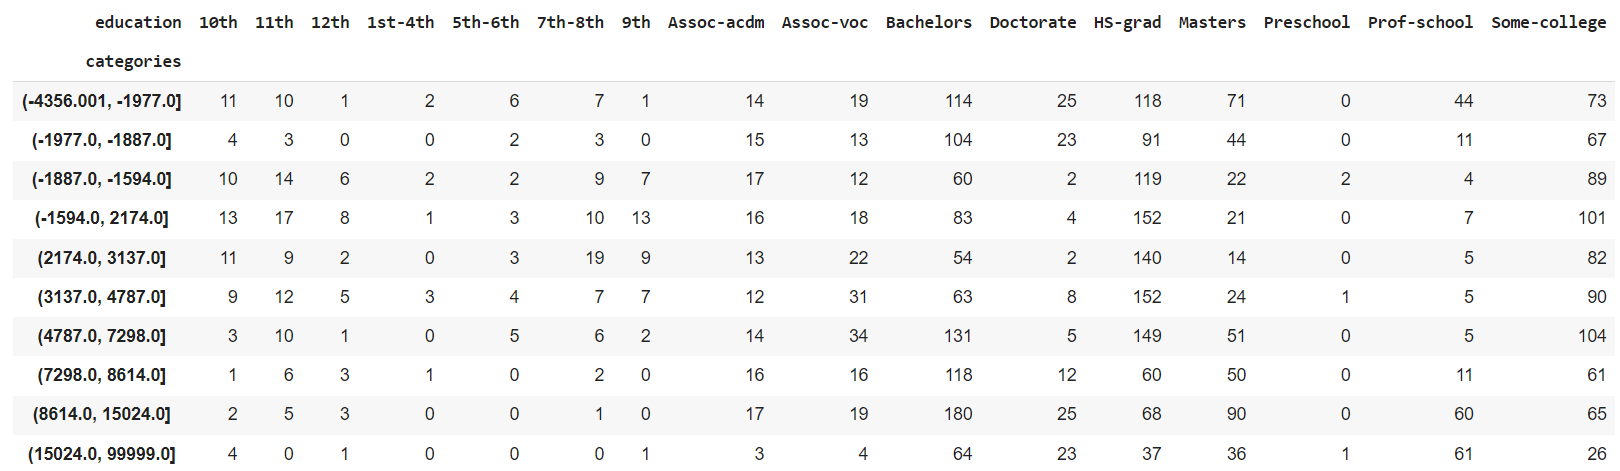

In [ ]:
summary_table = df[['education']].copy()
summary_table['capital.diff'] = df['capital.gain'] - df['capital.loss']
summary_table = summary_table[summary_table['capital.diff'] != 0].copy()
summary_table['categories'] = pd.qcut(summary_table['capital.diff'], q=10, duplicates='drop')

pd.pivot_table(
    summary_table,
    index='education',
    columns='categories',
    values='capital.diff',
    aggfunc='count',
    fill_value=0
)


/tmp/ipykernel_551/603681857.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


categories,"(-4356.001, -1977.0]","(-1977.0, -1887.0]","(-1887.0, -1594.0]","(-1594.0, 2174.0]","(2174.0, 3137.0]","(3137.0, 4787.0]","(4787.0, 7298.0]","(7298.0, 8614.0]","(8614.0, 15024.0]","(15024.0, 99999.0]"
education,,,,,,,,,,
10th,11,4,10,13,11,9,3,1,2,4
11th,10,3,14,17,9,12,10,6,5,0
12th,1,0,6,8,2,5,1,3,3,1
1st-4th,2,0,2,1,0,3,0,1,0,0
5th-6th,6,2,2,3,3,4,5,0,0,0
7th-8th,7,3,9,10,19,7,6,2,1,0
9th,1,0,7,13,9,7,2,0,0,1
Assoc-acdm,14,15,17,16,13,12,14,16,17,3
Assoc-voc,19,13,12,18,22,31,34,16,19,4


14) Женщины из каких стран получают в среднем большую зарплату (>50K) чаще.

In [ ]:
women = df[df['sex'] == 'Female']
women_income_share = women.groupby('native.country')['income'].apply(lambda s: (s == '>50K').mean())
women_income_share.sort_values(ascending=False).head(10)


KeyError: 'sex'

15) Создайте случайную колонку - magic_salary, которую нужно будет вычислить следующим образом: если зарплата небольшая (<50K), тогда случайно выберите число из диапазона [0,50]. Если зарплата выше 50K тогда из диапазона [51, 200]. Посчитайте среднюю зарплату в час для групп людей с одни уровнем образования на основе нашей случайной колонки magic_salary

In [ ]:
import numpy as np

rng = np.random.default_rng(42)
df_magic = df.copy()

df_magic['magic_salary'] = np.where(
    df_magic['income'] == '>50K',
    rng.integers(51, 201, size=len(df_magic)),
    rng.integers(0, 51, size=len(df_magic))
)
df_magic['magic_salary_per_hour'] = df_magic['magic_salary'] / df_magic['hours.per.week']

df_magic.groupby('education')['magic_salary_per_hour'].mean().sort_values(ascending=False).round(2)


,magic_salary_per_hour
education,
11th,1.03
10th,1.00
12th,0.86
7th-8th,0.83
9th,0.81
Some-college,0.80
Assoc-acdm,0.80
1st-4th,0.77
5th-6th,0.74


## Комплексное задание №2. Визуальный анализ данных. Часть 1

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

В этом задании Вам предлагается провести визуальный анализ датасета о прокатах велосипедов https://www.kaggle.com/c/bike-sharing-demand/data. Оригинальная задача предполагает построение модели предсказания количества прокатов в городе в зависимости от погоды.

Для каждого дня проката известны следующие признаки (как они были указаны в источнике данных):
- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)
- temp: температура в Цельсиях
- atemp: температура по ощущениям в Цельсиях
- hum: влажность
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду
- cnt: количество арендованных велосипедов (это целевой признак, его мы будем предсказывать)

Загрузите самостоятельно(!), с помощью pandas файл `bikes_rent.csv.gz` и выведите первые 5 строк. Ознакомьтесь с данными с помощью функций describe и info.

In [3]:

import kagglehub
path = kagglehub.dataset_download("annatrofy/bikes-rent")

df = pd.read_csv('/kaggle/input/bikes-rent/bikes_rent.csv')

df.head()


Using Colab cache for faster access to the 'bikes-rent' dataset.


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


In [ ]:
df.info()
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          731 non-null    int64  
 1   yr              731 non-null    int64  
 2   mnth            731 non-null    int64  
 3   holiday         731 non-null    int64  
 4   weekday         731 non-null    int64  
 5   workingday      731 non-null    int64  
 6   weathersit      731 non-null    int64  
 7   temp            731 non-null    float64
 8   atemp           731 non-null    float64
 9   hum             731 non-null    float64
 10  windspeed(mph)  731 non-null    float64
 11  windspeed(ms)   731 non-null    float64
 12  cnt             731 non-null    int64  
dtypes: float64(5), int64(8)
memory usage: 74.4 KB


,count,mean,std,min,25%,50%,75%,max
season,731.0,2.496580,1.110807,1.000000,2.000000,3.000000,3.000000,4.000000
yr,731.0,0.500684,0.500342,0.000000,0.000000,1.000000,1.000000,1.000000
mnth,731.0,6.519836,3.451913,1.000000,4.000000,7.000000,10.000000,12.000000
holiday,731.0,0.028728,0.167155,0.000000,0.000000,0.000000,0.000000,1.000000
weekday,731.0,2.997264,2.004787,0.000000,1.000000,3.000000,5.000000,6.000000
workingday,731.0,0.683995,0.465233,0.000000,0.000000,1.000000,1.000000,1.000000
weathersit,731.0,1.395349,0.544894,1.000000,1.000000,1.000000,2.000000,3.000000
temp,731.0,20.310776,7.505091,2.424346,13.820424,20.431653,26.872076,35.328347
atemp,731.0,23.717699,8.148059,3.953480,16.892125,24.336650,30.430100,42.044800
hum,731.0,62.789406,14.242910,0.000000,52.000000,62.666700,73.020850,97.250000


Давайте посмотрим на графиках, как целевой признак зависит количество прокатов (cnt) зависит от остальных признаков `df.columns[:-1]`.

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label sta

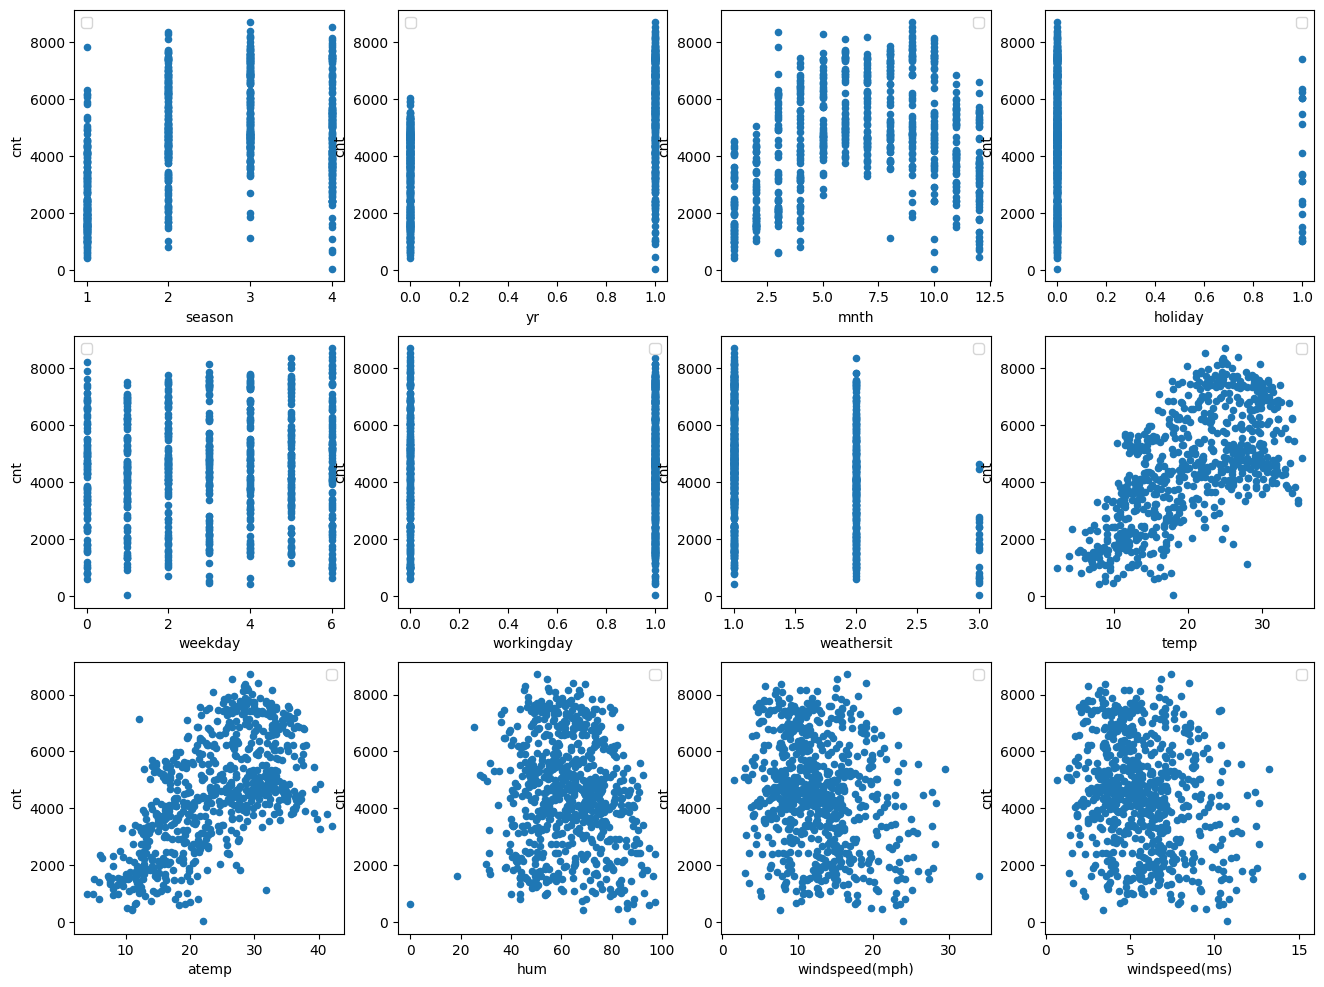

In [4]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df.columns[:-1]):
     df.plot(feature, "cnt", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])


### 1. Ответьте на вопросы:

#### Каков характер зависимости числа прокатов от месяца?





ответ:

Зависимость явно сезонная, а не линейная. В начале и конце года прокатов заметно меньше, затем к тёплому сезону их число растёт, а максимум держится примерно летом и в начале осени.


#### Укажите один или два признака, от которых число прокатов скорее всего зависит линейно
_(чем больше значение, тем больше прокатов или наоборот, например)_

Можете проверить результат с помощью lnplot.



Ответ:

Скорее всего, ближе всего к линейной зависимости признаки `temp` и `atemp`: чем выше температура, тем обычно больше прокатов. Ещё можно ожидать обратную, почти линейную связь с `windspeed(ms)` или `windspeed(mph)`: чем сильнее ветер, тем прокатов обычно меньше.


### 2. Корреляционная матрица

Напомним, что корреляция отражает взаимосвязь двух случайных величин. Она бывает положительная и отрицательная. Чем ближе коэффициент корреляции к нулю, тем меньше взаимосвязь. Чем больше абсолютная корреляци, тем взаимосвязь больше.

Постройте heatmap корреляционной матрицы. Матрица формируется средствами pandas, со стандартным значением параметров.



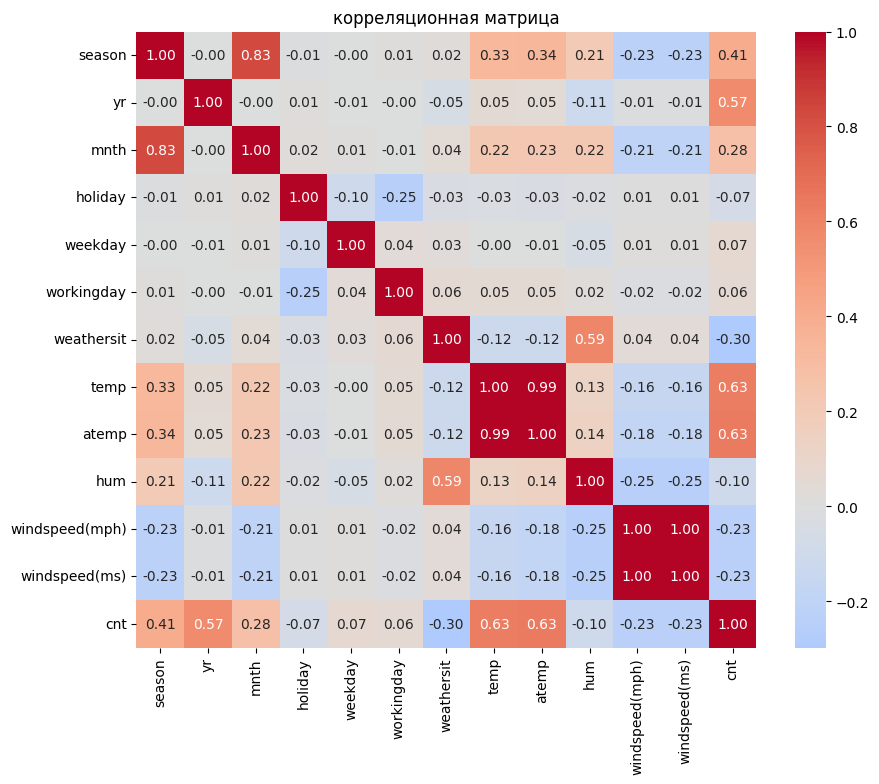

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('корреляционная матрица')
plt.show()


**Ответьте на вопрос**: с какими признаками количество прокатов коррелирует меньше всего (около 4 штуки). А с какими больше всего?

Ответ:

Слабее всего `cnt` обычно коррелирует с `holiday`, `weekday`, `workingday` и `hum`. Сильнее всего связь видна с `temp`, `atemp` и `yr`, а ещё заметна связь с `season` и отрицательная с качеством погоды `weathersit`.


### 3. Barpot

Постройте Bar-график суммарного количества прокатов велосипедов по месяцам за каждый год одновременно. (будет 24 столбика)



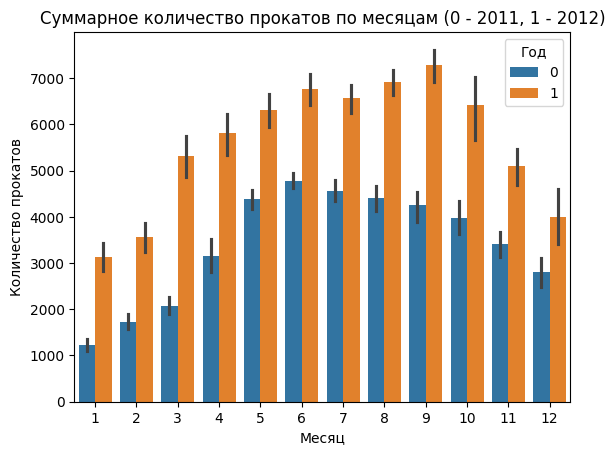

In [7]:
plt.figure()
sns.barplot(data=df, x='mnth', y='cnt', hue='yr')
plt.title('Суммарное количество прокатов по месяцам (0 - 2011, 1 - 2012)')
plt.xlabel('Месяц')
plt.ylabel('Количество прокатов')
plt.legend(title='Год')
plt.show()

**Ответьте на вопрос:** почему в предыдущем графике была такая большая корреляция между количеством прокатов и годом?

Ответ:

Большая корреляция с годом появилась потому, что в 2012 году сервисом в среднем пользовались заметно чаще, чем в 2011. Сам по себе номер года ничего не вызывает, но он отражает рост популярности сервиса со временем.


### 4. Countplot

Постройте countplot диаграммы для признаков `weekday`, `weathersit`,



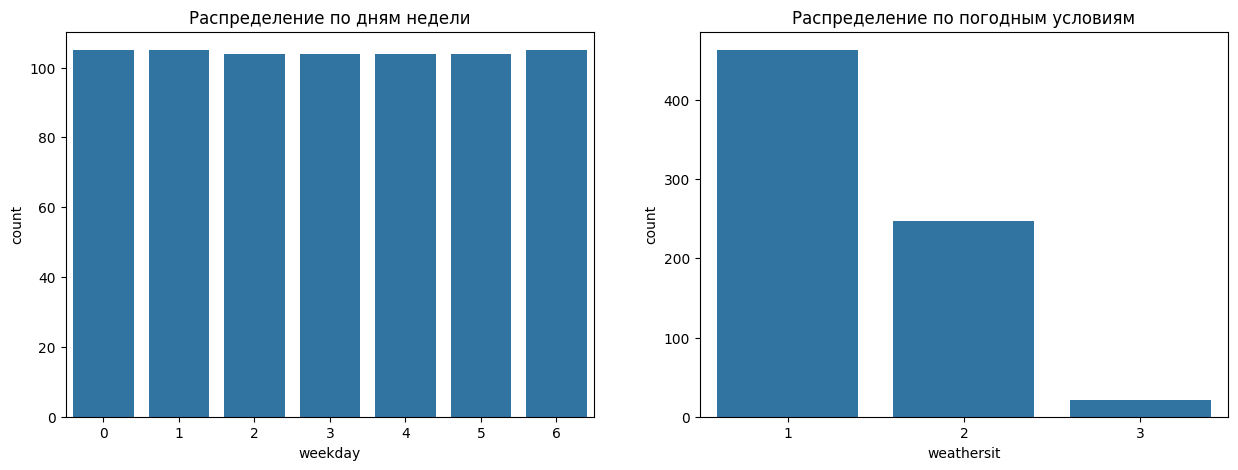

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, x='weekday', ax=axes[0])
axes[0].set_title('Распределение по дням недели')

sns.countplot(data=df, x='weathersit', ax=axes[1])
axes[1].set_title('Распределение по погодным условиям')

plt.show()

**Ответьте на вопрос:** что вы можете сказать о том, как формировался этот датасет.



Ответ:

Похоже, что датасет собирался регулярно по дням: значения `weekday` распределены почти равномерно, а значит в выборку, вероятно, попали подряд идущие календарные дни за длительный период. По `weathersit` видно, что хорошая и нормальная погода встречались намного чаще плохой.


**Ответьте на вопрос:** как называется распределение значений признака `weekday`?

Ответ:

Это дискретное равномерное распределение.


### 5. Распределение

Постройте распределение целевого признака.


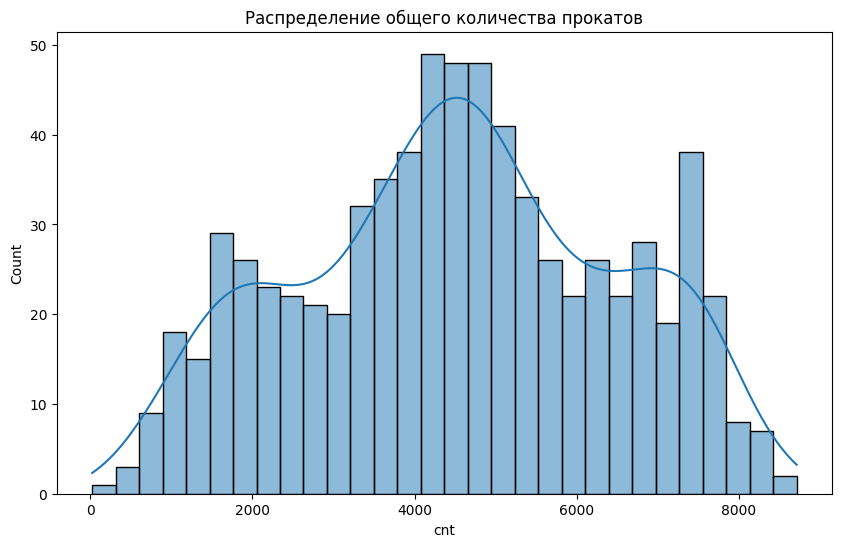

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['cnt'], kde=True, bins=30)
plt.title('Распределение общего количества прокатов')
plt.show()



**Ответьте на вопрос:** основываясь на графике, сколько приблизительно в среднем прокатов бывает в день?

Ответ:

По графику среднее число прокатов выглядит примерно на уровне 4500 в день.


### 6. Совместное распределение признаков

Постройте график совместного распределения признаков температура и ощущение температуры.



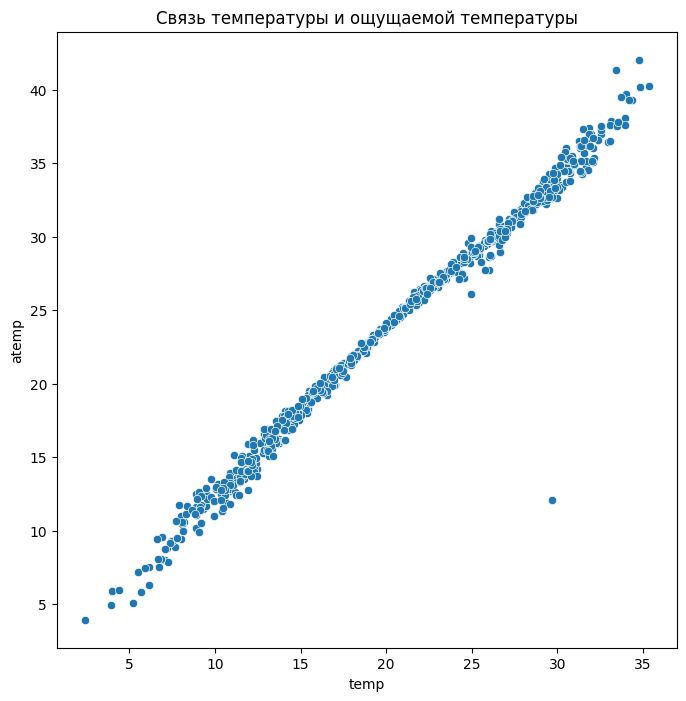

In [11]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df, x='temp', y='atemp')
plt.title('Связь температуры и ощущаемой температуры')
plt.show()


**Ответьте на вопрос:** вас в этом графике ничего не настораживает? Почему?

Ответ:

Да, настораживает почти идеальная линейная зависимость. Похоже, что `atemp` очень тесно вычисляется из `temp`, поэтому эти признаки почти дублируют друг друга и дают сильную мультиколлинеарность.


### 7. Боксплот (ящик с усами)

Постройте график распределения (боксплот) количества прокатов велосипедов по месяцам в зависимости от того рабочий это день или нет.




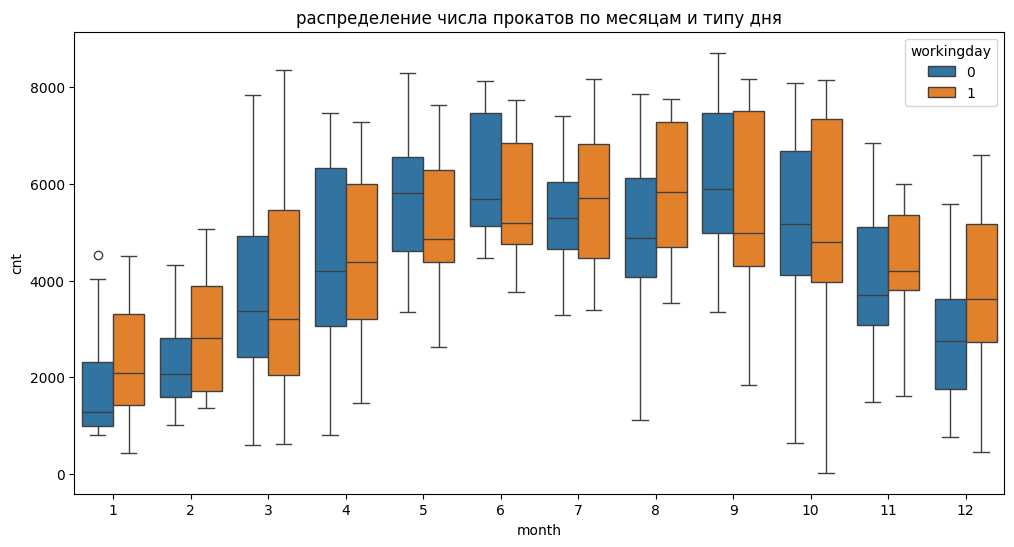

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='mnth', y='cnt', hue='workingday')
plt.title('распределение числа прокатов по месяцам и типу дня')
plt.xlabel('month')
plt.ylabel('cnt')
plt.legend(title='workingday')
plt.show()


**Ответьте на вопрос:** почему в некоторых месяцах чаще берут велосипеды в будний день, а в некоторые - в выходной.

Ответ:

Скорее всего, цель поездок меняется по сезону. В одни месяцы люди чаще берут велосипеды для поездок на работу и учёбу, поэтому будни лидируют. В другие месяцы, особенно в более тёплое и комфортное время, сильнее растёт доля прогулочных поездок, и тогда выходные могут выглядеть активнее.


## Комплексное задание №3. Визуальный анализ данных. Часть 2

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


In [14]:
score_columns = ['math score', 'reading score', 'writing score']


В этом задании Вам предлагается провести визуальный анализ датасета результатов экзаменов студентов  https://www.kaggle.com/spscientist/students-performance-in-exams.

Исходные данные загрузите самостоятельно!

In [15]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
df = pd.read_csv('/kaggle/input/students-performance-in-exams/StudentsPerformance.csv')

df.head()

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Ход задания:

#### 1. Постройте 3 графика, показывающих распределение результатов экзаменов (каждый график на предмет).


Графики должны быть в одном ряду и у них должен быть общий заголовок "Результаты экзаменов".

Для результатов каждого экзамена посчитайте медианные значения.


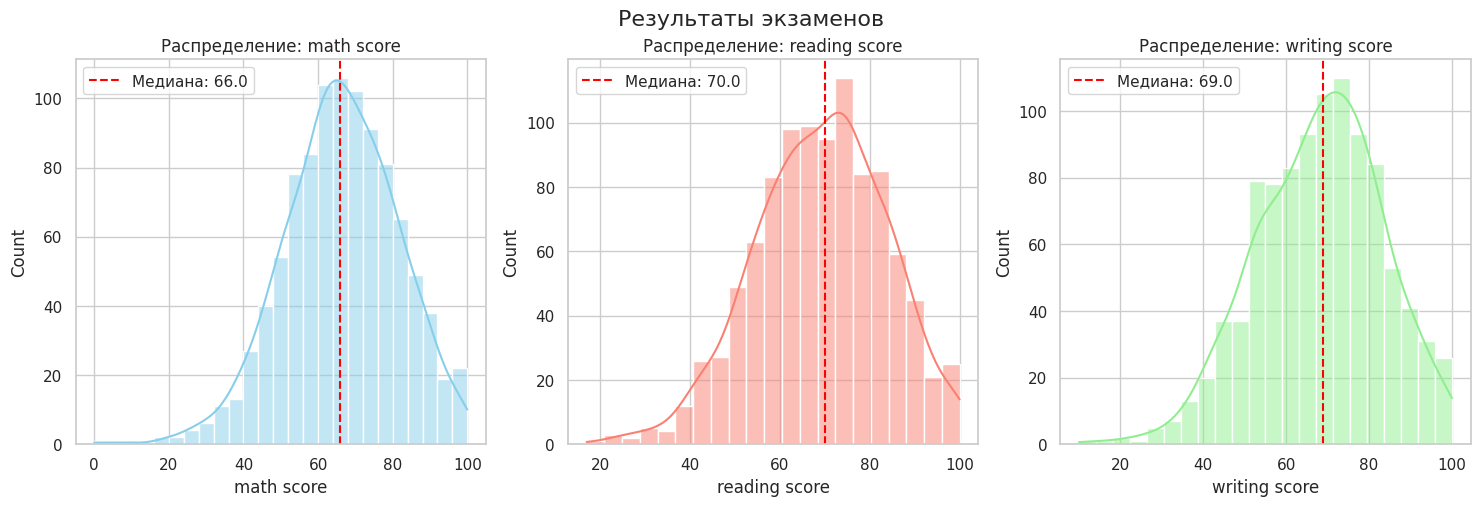

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Результаты экзаменов', fontsize=16)

subjects = ['math score', 'reading score', 'writing score']
colors = ['skyblue', 'salmon', 'lightgreen']

for i, subject in enumerate(subjects):
    sns.histplot(df[subject], kde=True, ax=axes[i], color=colors[i])
    median_val = df[subject].median()
    axes[i].axvline(median_val, color='red', linestyle='--', label=f'Медиана: {median_val}')
    axes[i].set_title(f'Распределение: {subject}')
    axes[i].legend()

plt.show()

#### 2. Образование родителей
Какие уровни образование есть в столбце *'parental level of education'* и сколько строк в датафрейме соответствует каждому уровню?

Постройте график и ответьте на вопрос ниже

Отличаются ли баллы по математике у детей с разным образованием родителей?
Постройте график, где по оси Х находятся уровни образования родителей, а по У - баллы по математике.


parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


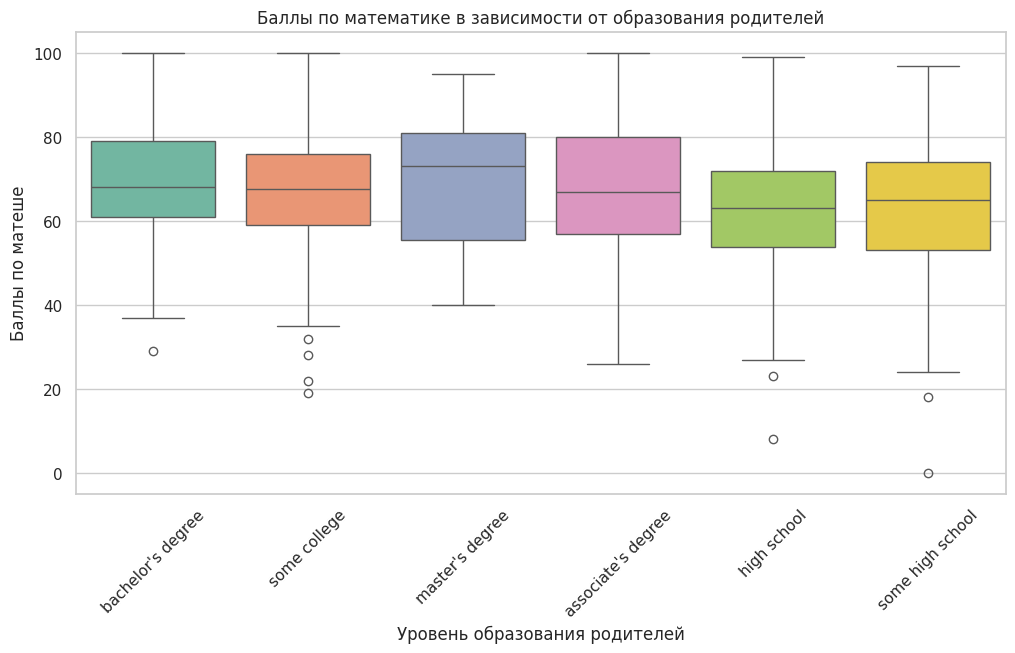

In [20]:
print(df['parental level of education'].value_counts())

plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='parental level of education', y='math score',
            palette='Set2', hue='parental level of education')

plt.xticks(rotation=45)

plt.title('Баллы по математике в зависимости от образования родителей')
plt.xlabel('Уровень образования родителей')
plt.ylabel('Баллы по матеше')

plt.show()


#### 3. Выведите число студенток, набравших больше 90 баллов по всем предметам.


In [22]:
top_females = df[(df['gender'] == 'female') &
                 (df['math score'] > 90) &
                 (df['reading score'] > 90) &
                 (df['writing score'] > 90)]
print(f"Число таких студенток: {len(top_females)}")

Число таких студенток: 17


#### 4. Сравните баллы у студентов разных полов. Используя agg() выведите минимальное, максимальное и медианное значение


In [23]:
df.groupby('gender')[score_columns].agg(['min', 'max', 'median'])


math score             reading score             writing score       \
              min  max median           min  max median           min  max   
gender                                                                       
female          0  100   65.0            17  100   73.0            10  100   
male           27  100   69.0            23  100   66.0            15  100   

               
       median  
gender         
female   74.0  
male     64.0

#### 5. Выясните, влияет ли обед и подготовка к тесту на средний балл студентов разного пола
###### (подсказка: используете  [pd.agg()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.agg.html))

In [24]:
df['average score'] = df[score_columns].mean(axis=1)

df.groupby(['gender', 'lunch', 'test preparation course'])[
    score_columns + ['average score']
].mean().round(2)


math score  reading score  \
gender lunch        test preparation course                              
female free/reduced completed                     60.79          73.43   
                    none                          52.89          63.83   
       standard     completed                     71.13          79.80   
                    none                          66.53          73.39   
male   free/reduced completed                     65.64          65.79   
                    none                          60.61          59.08   
       standard     completed                     75.96          72.60   
                    none                          69.83          64.72   

                                             writing score  average score  
gender lunch        test preparation course                                
female free/reduced completed                        74.37          69.53  
                    none                             61.78          59.50  
       standard     completed                        81.51          77.48  
                    none                             72.97          70.96  
male   free/reduced completed                        65.74          65.72  
                    none                             55.29          58.32  
       standard     completed                        71.98          73.51  
                    none                             61.91          65.49

#### 6. Постройте график, показывающий зависимость уровня образования родителей от их расы

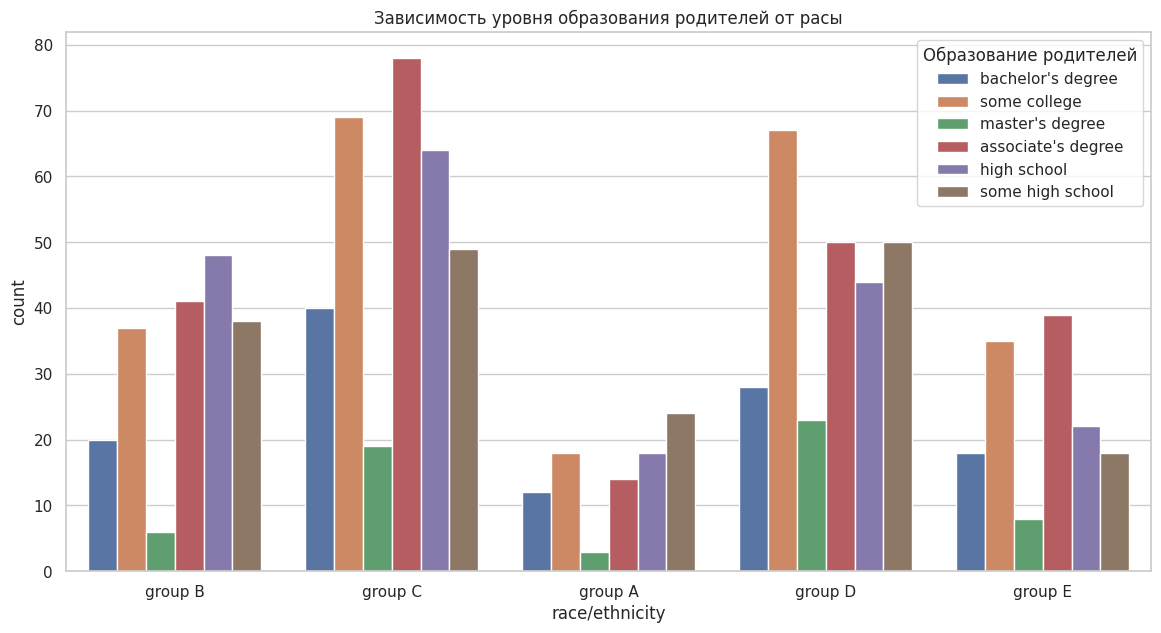

In [26]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='race/ethnicity', hue='parental level of education')
plt.title('Зависимость уровня образования родителей от расы')
plt.legend(title='Образование родителей', bbox_to_anchor=(1, 1))
plt.show()


#### 7. Постройте график, показывающий зависимость прохождения подготовительного теста от уровня образования родителей.


Кто чаще ходит на курсы: дети, родители которых закончили только старшую школу, или дети, чьи родители получили степень бакалавра\магистра?

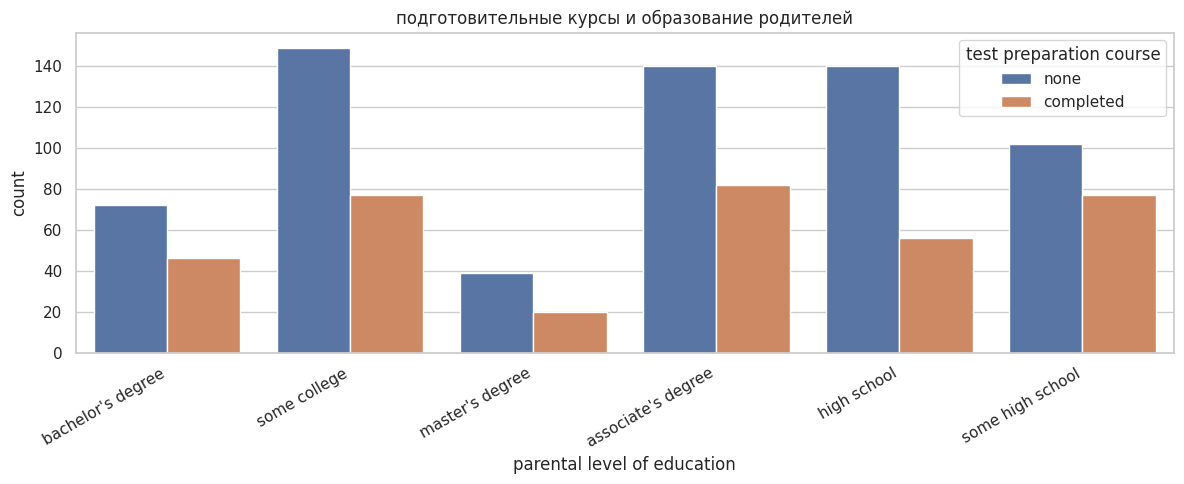

,completed
parental level of education,
some high school,0.430168
bachelor's degree,0.389831
associate's degree,0.369369
some college,0.340708
master's degree,0.338983
high school,0.285714


In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='parental level of education', hue='test preparation course')
plt.xticks(rotation=30, ha='right')
plt.title('подготовительные курсы и образование родителей')
plt.tight_layout()
plt.show()

course_share = (
    df.assign(completed=df['test preparation course'].eq('completed'))
      .groupby('parental level of education')['completed']
      .mean()
      .sort_values(ascending=False)
)

display(course_share)


#### 8. Постройте plot.pie, показывающий, сколько людей сдали\не сдали экзамен по математике.

Сдавшим считается человек, набравший 40 баллов.

###### Подсказка: создайте столбец в датафрейме, который содержит результат сдачи (сдал или не сдал)

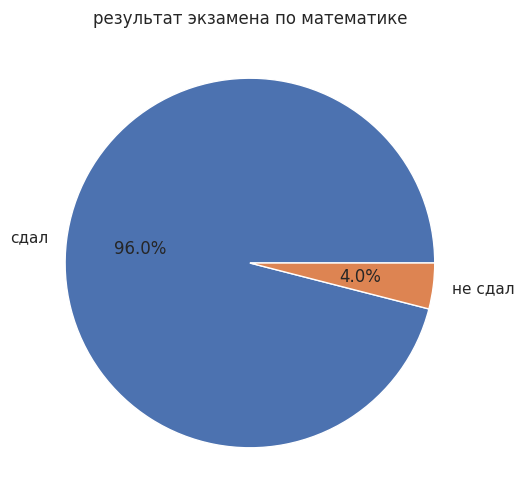

In [34]:
df['math_result'] = df['math score'].ge(40).map({True: 'сдал', False: 'не сдал'})

df['math_result'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6, 6),
    ylabel='',
    title='результат экзамена по математике'
)
plt.show()


#### 9. Постройте plot.pie, показывающий распределение студентов по оценкам

Оценки студентов выставляются по шкале:<br>
0  - 40 marks : grade E<br>
41 - 60 marks : grade D<br>
60 - 70 marks : grade C<br>
70 - 80 marks : grade B<br>
80 - 90 marks : grade A<br>
90 - 100 marks : grade O<br>

Для этого посчитайте сумму результатов за 3 экзамена и найдите среднее. Оценка выставляется по среднему значению. Если студент не сдал математику(даже если средний балл выше 40), он получает Е

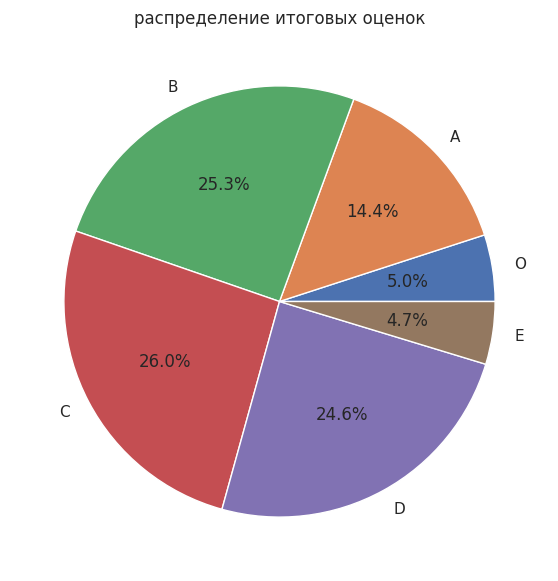

In [32]:
df['average_exam_score'] = df[score_columns].mean(axis=1)

def get_grade(row):
    if row['math score'] < 40:
        return 'E'
    if row['average_exam_score'] <= 40:
        return 'E'
    if row['average_exam_score'] <= 60:
        return 'D'
    if row['average_exam_score'] <= 70:
        return 'C'
    if row['average_exam_score'] <= 80:
        return 'B'
    if row['average_exam_score'] <= 90:
        return 'A'
    return 'O'

df['final_grade'] = df.apply(get_grade, axis=1)

grade_order = ['O', 'A', 'B', 'C', 'D', 'E']
df['final_grade'].value_counts().reindex(grade_order).plot.pie(
    autopct='%1.1f%%',
    figsize=(7, 7),
    ylabel='',
    title='распределение итоговых оценок'
)
plt.show()


#### 10. Постройте countplot, показывающий зависимость между итоговой оценкой студентов и его полом. Студенты какого пола получили больше оценок О, А, В

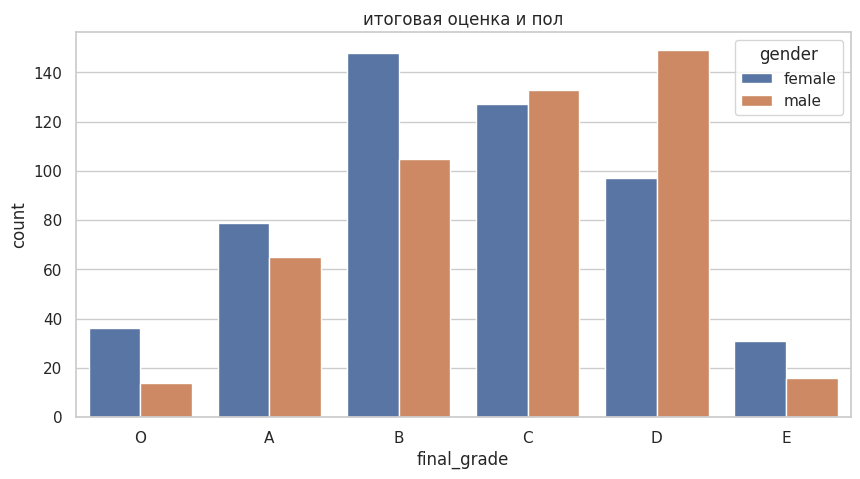

gender,female,male
final_grade,,
O,36,14
A,79,65
B,148,105


In [33]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='final_grade', hue='gender', order=['O', 'A', 'B', 'C', 'D', 'E'])
plt.title('итоговая оценка и пол')
plt.show()

pd.crosstab(df['final_grade'], df['gender']).loc[['O', 'A', 'B']]
